In [ ]:
import numpy as np
class linear_regression():
    def __init__(self,learningrate,noofiterations):
        self.learningrate=learningrate
        self.noofiterations=noofiterations

    def fit(self,x,y):
        self.m, self.n=x.shape#no of taining samples and no of features
        self.w=np.zeros(self.n)
        self.b=0
        self.x=x
        self.y=y
        for i in range(self.noofiterations):
            self.update_weights()
    def update_weights(self):
        ypred=self.predict(self.x)
        dw=-(2*(self.x.T).dot(self.y-ypred))/self.m
        db=-2*np.sum(self.y-ypred)/self.m
        self.w=self.w-self.learningrate*dw
        self.b=self.b-self.learningrate*db


    def predict(self,x):
      return x.dot(self.w)+self.b




In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
data=pd.read_csv('/content/salary_data.csv')
data.isnull().sum()

FileNotFoundError: [Errno 2] No such file or directory: '/content/salary_data.csv'

In [ ]:
data.shape


(30, 2)

In [ ]:
x=data.iloc[:,:-1].values
y=data.iloc[:,1].values

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=2)

In [ ]:
model1=linear_regression(learningrate=0.01,noofiterations=1000)

In [ ]:
model1.fit(x_train,y_train)

In [ ]:
print(model1.w[0])
print(model1.b)

9580.301196603597
23226.38946603212


In [ ]:
salary=9580.301196603597*(2)+23226.38946603212

In [ ]:
print(salary)

42386.991859239315


In [ ]:
testp=model1.predict(x_test)
print(testp)


[ 35680.78102162  33764.7207823   66337.74485075  58673.50389347
  91246.52796192  80708.19664565 101784.85927818  51967.29305584
  42386.99185924  88372.43760294]


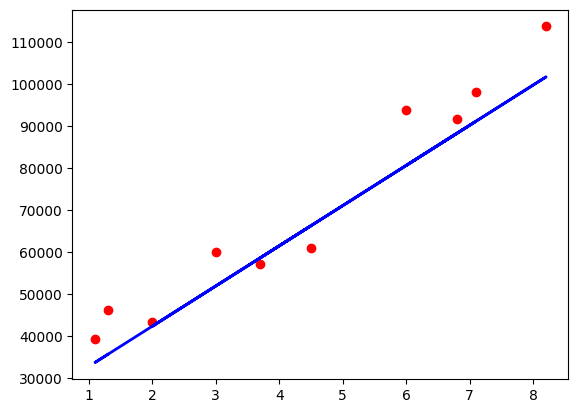

In [ ]:
plt.scatter(x_test,y_test ,color='red')
plt.plot(x_test,testp,color='blue',linewidth=2)
plt.show()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [ ]:
df.isnull().sum()

,0
day,0
month,1
year,1
Temperature,1
RH,1
Ws,1
Rain,1
FFMC,1
DMC,1
DC,1


In [ ]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [ ]:
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.0+ KB


In [ ]:
df[["Region"]]=df[["Region"]].astype(int)

In [ ]:
df=df.dropna().reset_index(drop=True)

In [ ]:
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


In [ ]:
df=df.drop(122).reset_index(drop=True)

In [ ]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,02,06,2012,30,73,13,4,55.7,2.7,7.8,0.6,2.9,0.2,not fire,1


In [ ]:
df.columns=df.columns.str.strip()

In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
#changing data types
df[['month','year','Temperature','RH','Ws']]=df[['month','year','Temperature','RH','Ws']].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          242 non-null    int64 
 1   month        242 non-null    int64 
 2   year         242 non-null    int64 
 3   Temperature  242 non-null    int64 
 4   RH           242 non-null    int64 
 5   Ws           242 non-null    int64 
 6   Rain         242 non-null    object
 7   FFMC         242 non-null    object
 8   DMC          242 non-null    object
 9   DC           242 non-null    object
 10  ISI          242 non-null    object
 11  BUI          242 non-null    object
 12  FWI          242 non-null    object
 13  Classes      242 non-null    object
 14  Region       242 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.5+ KB


In [ ]:
objects=[features for features in df.columns if df[features].dtypes=='O']

In [ ]:
for i in objects:
    if i != 'Classes':
        df[i] = df[i].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          242 non-null    float64
 1   month        242 non-null    int64  
 2   year         242 non-null    int64  
 3   Temperature  242 non-null    int64  
 4   RH           242 non-null    int64  
 5   Ws           242 non-null    int64  
 6   Rain         242 non-null    float64
 7   FFMC         242 non-null    float64
 8   DMC          242 non-null    float64
 9   DC           242 non-null    float64
 10  ISI          242 non-null    float64
 11  BUI          242 non-null    float64
 12  FWI          242 non-null    float64
 13  Classes      242 non-null    object 
 14  Region       242 non-null    int64  
dtypes: float64(8), int64(6), object(1)
memory usage: 28.5+ KB


In [ ]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,242.000000,242.000000,242.0,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,15.822314,7.508264,2012.0,32.152893,62.004132,15.508264,0.763223,77.928099,14.730992,49.601240,4.759504,16.747934,7.063636,0.495868
std,8.809501,1.112888,0.0,3.635545,14.847635,2.808171,2.007354,14.316912,12.393811,47.690192,4.154248,14.229690,7.442923,0.501019
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.250000,14.000000,0.000000,72.375000,5.800000,14.325000,1.400000,6.025000,0.725000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.500000,11.300000,33.250000,3.500000,12.450000,4.450000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.750000,17.000000,0.500000,88.300000,20.850000,70.050000,7.275000,22.775000,11.525000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [ ]:
df.to_csv('Algerian_forest_cleaned.csv',index=False)

In [ ]:
#Eda
df1=df
df1.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1.0,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2.0,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3.0,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4.0,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5.0,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df=df.drop(['day','month','year'],axis=1)

In [ ]:
#encoding the categories
df1['Classes']=np.where(df1['Classes'].str.contains('not fire'),0,1)

In [ ]:
df1['Classes'].value_counts()

,count
Classes,
1,137
0,105


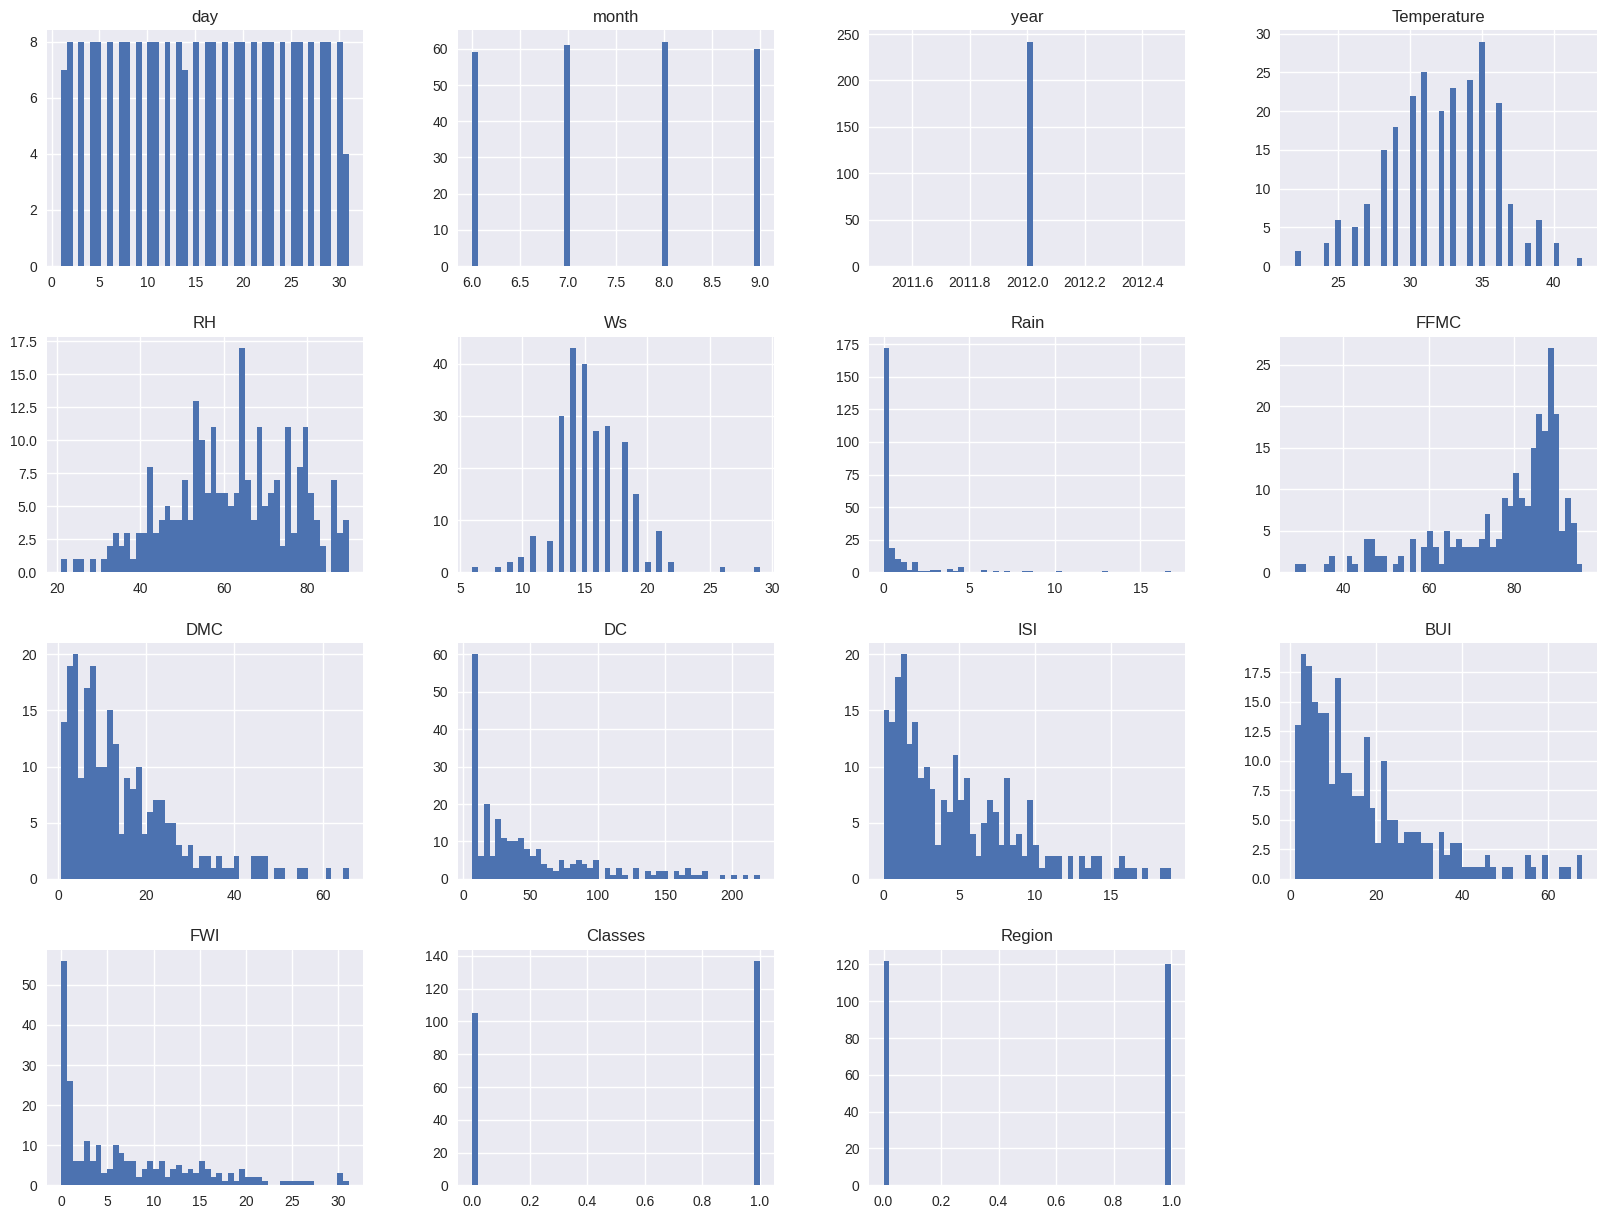

In [ ]:
plt.style.use('seaborn-v0_8')
df1.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
percentage=df1['Classes'].value_counts(normalize=True)*100

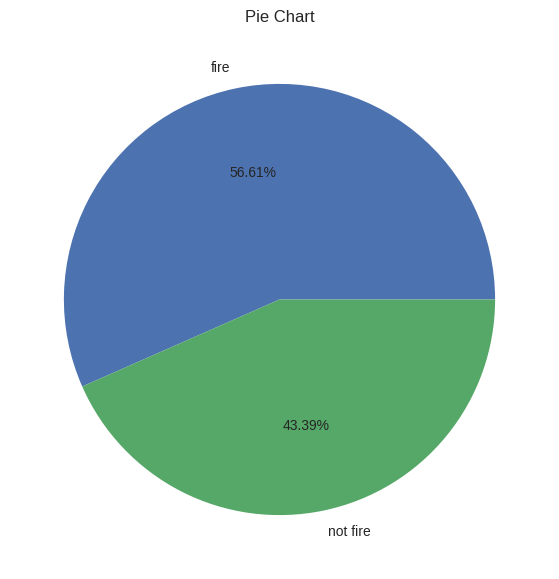

In [ ]:
classlabels=["fire",'not fire']
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.2f%%')
plt.title('Pie Chart')
plt.show()

In [ ]:
df1.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
day,1.000000,-0.009796,NaN,0.097502,-0.072323,0.039560,-0.113399,0.217140,0.488513,0.525822,0.175010,0.514349,0.347035,0.196645,0.007824
month,-0.009796,1.000000,NaN,-0.057232,-0.038046,-0.047156,0.034777,0.009022,0.062810,0.122326,0.060385,0.080075,0.077933,0.017776,0.007503
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,0.097502,-0.057232,NaN,1.000000,-0.651791,-0.285644,-0.326499,0.679270,0.486494,0.376720,0.604948,0.460533,0.567506,0.517203,0.270295
RH,-0.072323,-0.038046,NaN,-0.651791,1.000000,0.248148,0.222604,-0.644536,-0.407180,-0.225293,-0.686103,-0.352357,-0.580109,-0.430794,-0.406348
Ws,0.039560,-0.047156,NaN,-0.285644,0.248148,1.000000,0.171896,-0.175324,-0.005819,0.075031,0.003408,0.026542,0.027768,-0.076262,-0.176928
Rain,-0.113399,0.034777,NaN,-0.326499,0.222604,0.171896,1.000000,-0.546470,-0.289482,-0.298600,-0.348334,-0.300574,-0.325112,-0.380263,-0.039965
FFMC,0.217140,0.009022,NaN,0.679270,-0.644536,-0.175324,-0.546470,1.000000,0.601527,0.505185,0.738754,0.589881,0.689822,0.768069,0.229726
DMC,0.488513,0.062810,NaN,0.486494,-0.407180,-0.005819,-0.289482,0.601527,1.000000,0.875511,0.679150,0.982178,0.875405,0.583760,0.196981
DC,0.525822,0.122326,NaN,0.376720,-0.225293,0.075031,-0.298600,0.505185,0.875511,1.000000,0.506897,0.941809,0.738663,0.509202,-0.075412


<Axes: >

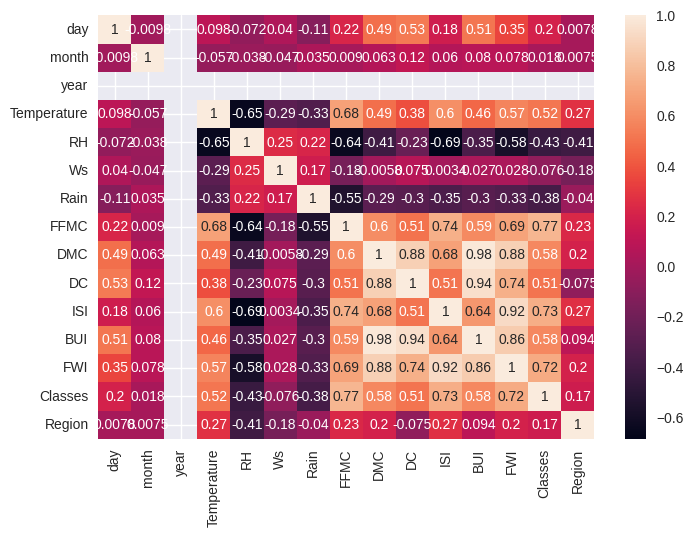

In [ ]:
sns.heatmap(df1.corr(),annot=True)

<Axes: ylabel='FWI'>

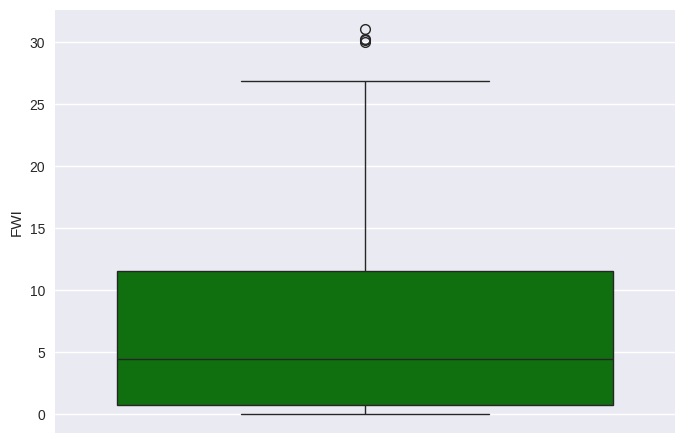

In [ ]:
sns.boxplot(df1['FWI'],color='green')

Text(0.5, 0, 'Months')

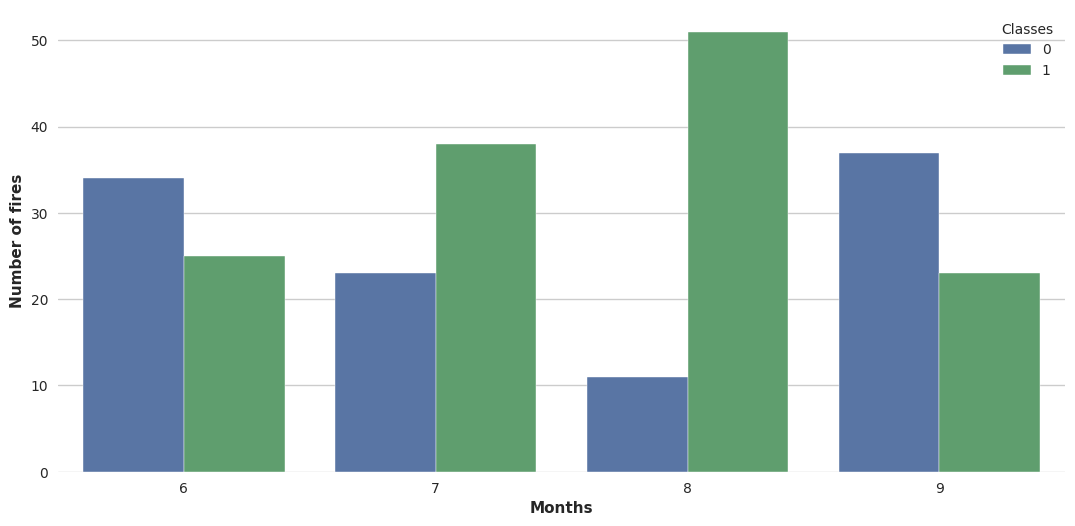

In [ ]:
dftemp=df1.loc[df['Region']==1]

plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df1)
plt.ylabel('Number of fires',weight='bold')
plt.xlabel('Months',weight='bold')


In [4]:
df=pd.read_csv('Algerian_forest_cleaned.csv')

In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [6]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [8]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [9]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [12]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [13]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [14]:
X=df.drop('FWI',axis=1)
y=df['FWI']

In [15]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [17]:
#feature selection
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

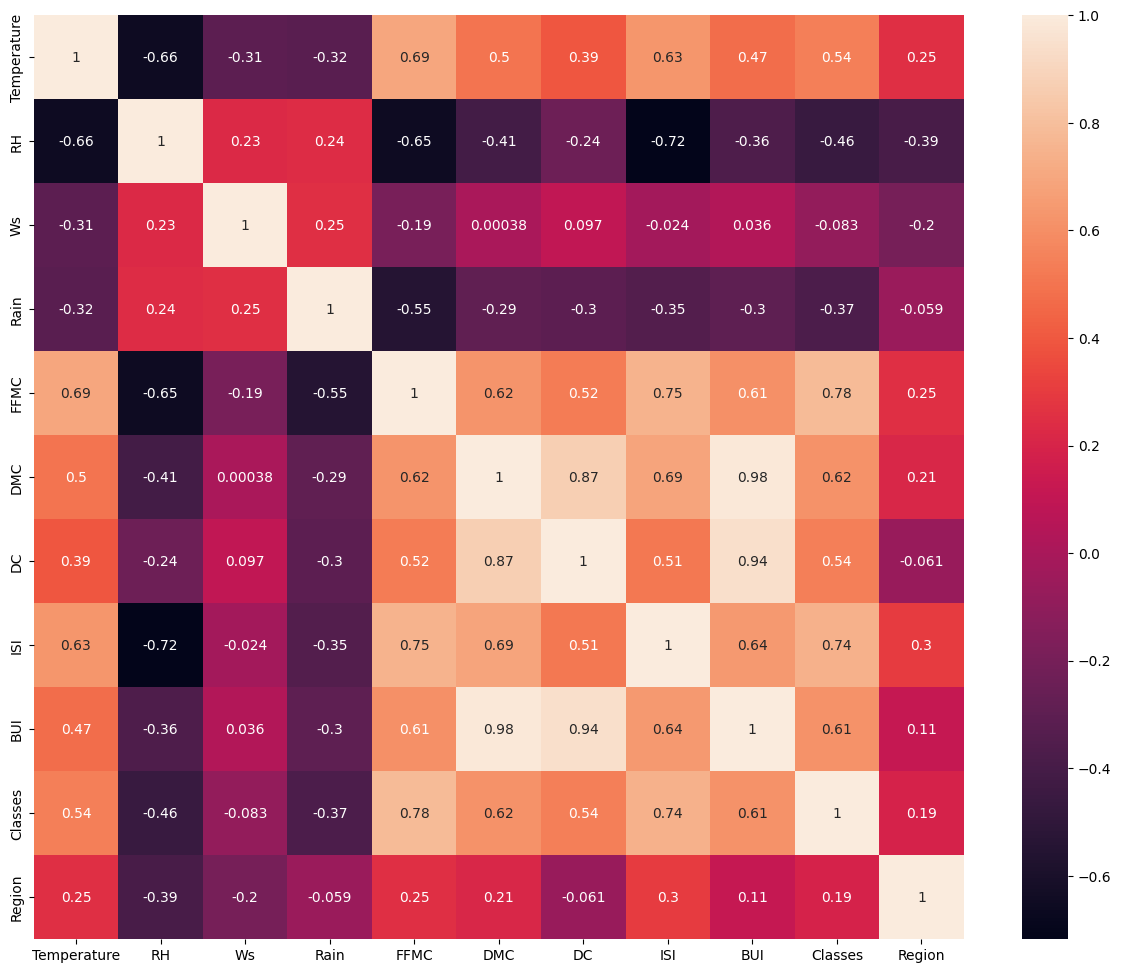

In [18]:
#checking for multicolinearity
plt.figure(figsize=(15,12))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [19]:
def correlation(dataset,threshold):
  col_corr=set()
  corrmatrix=dataset.corr()
  for i in range(len(corrmatrix.columns)):
    for j in range(i):
      if abs(corr.iloc[i,j])>threshold :
        colname=corrmatrix.columns[i]
        col_corr.add(colname)
  return col_corr


In [20]:
corr_features = correlation(X_train, 0.85)

X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)

In [18]:
# drop features when correlation is more than 0.85


In [21]:
X_train.drop(correlation(X_train,0.85),axis=1,inplace=True)


In [22]:
X_test.drop(correlation(X_test,0.85),axis=1,inplace=True)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

<Axes: >

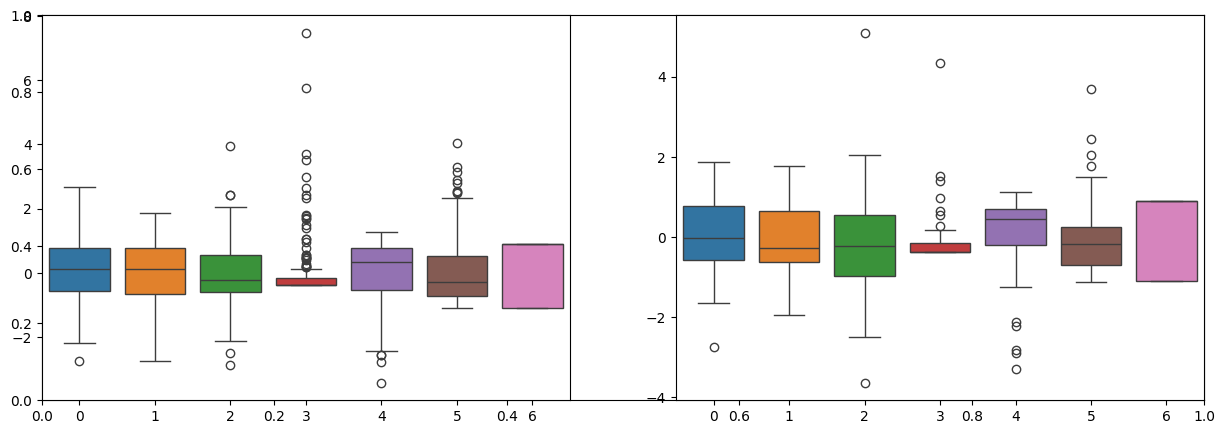

In [24]:
###boxplots
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.subplot(1,2,2)
sns.boxplot(data=X_test)



In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
linreg=LinearRegression()
linreg.fit(X_train,y_train)
y_pred=linreg.predict(X_test)
print('MSE:',mean_squared_error(y_test,y_pred))
print('R2:',r2_score(y_test,y_pred))

MSE: 6.6671949912904305
R2: 0.8493648166120984


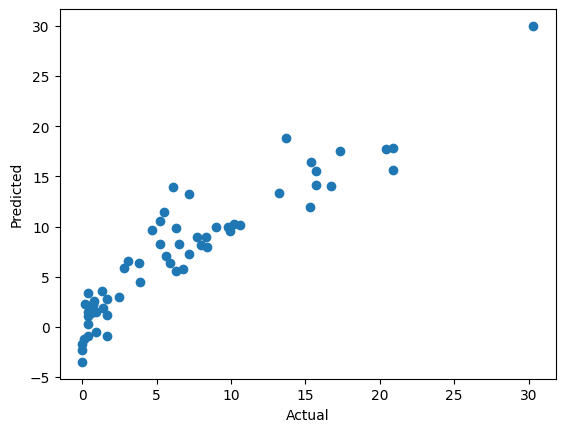

In [26]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

MSE: 8.023932281563686
R2: 0.8187113902766614
mae 2.1809301934910366


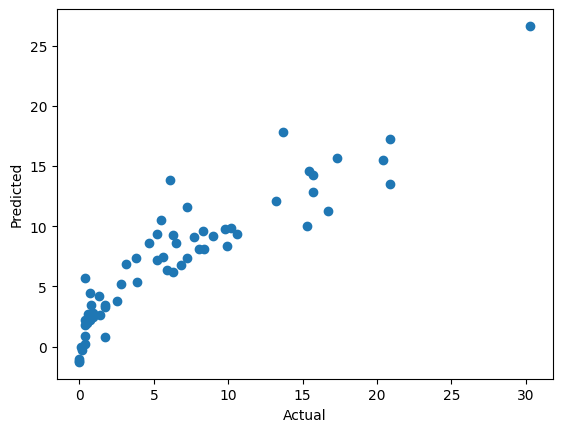

In [27]:
from sklearn.linear_model import Lasso
las=Lasso()
las.fit(X_train,y_train)
y_pred=las.predict(X_test)
print('MSE:',mean_squared_error(y_test,y_pred))
print('R2:',r2_score(y_test,y_pred))
print('mae',mean_absolute_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

MSE: 6.662628329585233
R2: 0.8494679934239858
mae 1.9000328007824643


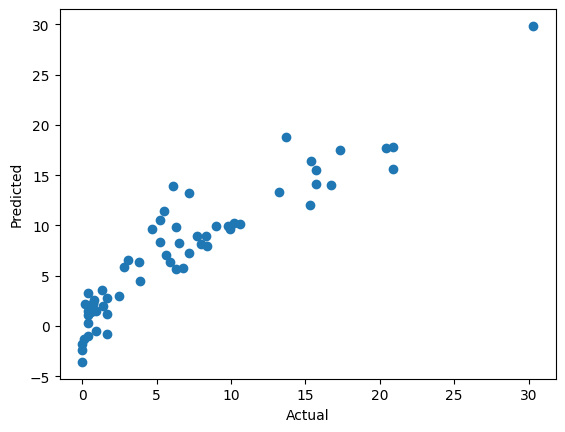

In [28]:
from sklearn.linear_model import Lasso,Ridge
rig=Ridge()
rig.fit(X_train,y_train)
y_pred=rig.predict(X_test)
print('MSE:',mean_squared_error(y_test,y_pred))
print('R2:',r2_score(y_test,y_pred))
print('mae',mean_absolute_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

MSE: 10.359990569275574
R2: 0.7659316877129901
mae 2.598558092409741


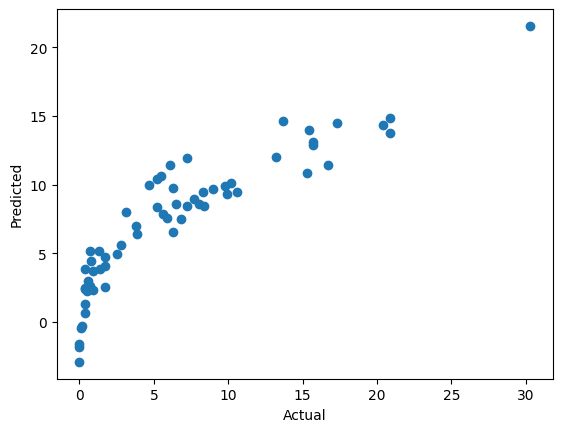

In [29]:
#elastic
from sklearn.linear_model import Lasso,ElasticNet
elas=ElasticNet()
elas.fit(X_train,y_train)
y_pred=elas.predict(X_test)
print('MSE:',mean_squared_error(y_test,y_pred))
print('R2:',r2_score(y_test,y_pred))
print('mae',mean_absolute_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [30]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train,y_train)
y_pred=lassocv.predict(X_test)

In [32]:
lassocv.alpha_

np.float64(0.01353889991862901)

In [31]:
from sklearn.linear_model import RidgeCV
Ridgecv=LassoCV(cv=5)
Ridgecv.fit(X_train,y_train)
y_pred=lassocv.predict(X_test)
print('mae',mean_absolute_error(y_test,y_pred))
print('r2',r2_score(y_test,y_pred))

mae 1.8992477551452775
r2 0.8493579800852002


In [33]:
Ridgecv.alpha_

np.float64(0.01353889991862901)

In [34]:
Ridgecv.alphas

In [36]:
Ridgecv.get_params()

{'alphas': None,
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'max_iter': 1000,
 'n_alphas': 100,
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': False}

In [37]:
from sklearn.linear_model import ElasticNetCV
elascv=LassoCV(cv=5)
elascv.fit(X_train,y_train)
y_pred=elascv.predict(X_test)
print('mae',mean_absolute_error(y_test,y_pred))
print('r2',r2_score(y_test,y_pred))

mae 1.8992477551452775
r2 0.8493579800852002


In [34]:
##pickling for ml model preprocessing

In [38]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(rig,open('model.pkl','wb'))